# LSTM and GRU RNNs on the Penn Tree Bank Dataset

### This Notebook includes a reimplementation of the "small" **LSTM** model as described in "Recurrent Neural Network Regularization", by Zaremba et al. (https://arxiv.org/abs/1409.2329). The notebook goes further than the paper by applying the **GRU (Gated Recurrent Units)** model to the same data.


###Loading the data

In [1]:
!wget http://www.fit.vutbr.cz/~imikolov/rnnlm/simple-examples.tgz

!tar -xvzf simple-examples.tgz

--2024-09-26 03:26:20--  http://www.fit.vutbr.cz/~imikolov/rnnlm/simple-examples.tgz
Resolving www.fit.vutbr.cz (www.fit.vutbr.cz)... 147.229.9.23, 2001:67c:1220:809::93e5:917
Connecting to www.fit.vutbr.cz (www.fit.vutbr.cz)|147.229.9.23|:80... connected.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: https://www.fit.vut.cz/~imikolov/rnnlm/simple-examples.tgz [following]
--2024-09-26 03:26:21--  https://www.fit.vut.cz/~imikolov/rnnlm/simple-examples.tgz
Resolving www.fit.vut.cz (www.fit.vut.cz)... 147.229.9.65, 2001:67c:1220:809::93e5:941
Connecting to www.fit.vut.cz (www.fit.vut.cz)|147.229.9.65|:443... connected.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: https://www.fit.vut.cz/person/imikolov/public/rnnlm/simple-examples.tgz [following]
--2024-09-26 03:26:22--  https://www.fit.vut.cz/person/imikolov/public/rnnlm/simple-examples.tgz
Reusing existing connection to www.fit.vut.cz:443.
HTTP request sent, awaiting response... 200 OK


Main imports

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
import math
from collections import Counter
from itertools import chain
import numpy as np

In [3]:
def load_data(file):
    with open(file, 'r') as f:
        text = f.read().replace("\n", " <eos> ").strip()
    return text.split()

train_file = 'simple-examples/data/ptb.train.txt'
valid_file = 'simple-examples/data/ptb.valid.txt'
test_file = 'simple-examples/data/ptb.test.txt'

train_data = load_data(train_file)
valid_data = load_data(valid_file)
test_data = load_data(test_file)

Starting Parameters

In [4]:
BATCH_SIZE = 20
SEQ_LENGTH = 20
LAYERS = 2
RNN_SIZE = 200
DROPOUT = 0
INIT_WEIGHT = 0.1
LR = 2
VOCAB_SIZE = 10000
MAX_EPOCH = 13
DECAY_EPOCH = 7
MAX_GRAD_NORM = 5

Building the Vocab (A mapping of unique integer indices)

In [5]:
def build_vocab(data, vocab_size=VOCAB_SIZE):
    counter = Counter(data)
    most_common = counter.most_common(vocab_size - 1)
    vocab = {word: i+1 for i, (word, _) in enumerate(most_common)}
    vocab["<unk>"] = 0
    return vocab

vocab = build_vocab(train_data)

Setting Device to GPU

In [6]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

Converting words to PyTorch tensor of word indices

In [7]:
def text_to_tensor(data, vocab):
    return torch.tensor([vocab.get(word, vocab["<unk>"]) for word in data], dtype=torch.long)

train_data = text_to_tensor(train_data, vocab)
valid_data = text_to_tensor(valid_data, vocab)
test_data = text_to_tensor(test_data, vocab)

## LSTM Model (PyTorch nn.Module)




In [8]:
class LSTMModel(nn.Module):
    def __init__(self, vocab_size, rnn_size, layers, dropout):
        super(LSTMModel, self).__init__()
        self.drop = nn.Dropout(dropout)
        self.encoder = nn.Embedding(vocab_size, rnn_size)
        self.lstm = nn.LSTM(rnn_size, rnn_size, layers, dropout=dropout)
        self.decoder = nn.Linear(rnn_size, vocab_size)
        self.init_weights()
        self.rnn_size = rnn_size
        self.layers = layers

    def init_weights(self):
        initrange = INIT_WEIGHT
        self.encoder.weight.data.uniform_(-initrange, initrange)
        self.decoder.weight.data.uniform_(-initrange, initrange)
        self.decoder.bias.data.zero_()

    def forward(self, input, hidden):
        emb = self.drop(self.encoder(input))
        output, hidden = self.lstm(emb, hidden)
        output = self.drop(output)
        decoded = self.decoder(output.view(output.size(0) * output.size(1), output.size(2)))
        return decoded.view(output.size(0), output.size(1), decoded.size(1)), hidden

    def init_hidden(self, bsize):
        weight = next(self.parameters())
        return (weight.new_zeros(LAYERS, bsize, RNN_SIZE),
                weight.new_zeros(LAYERS, bsize, RNN_SIZE))

Detaching hidden states from history by creating new tensors

In [9]:
def detach_hidden(h):
    if isinstance(h, torch.Tensor):
        return h.detach()
    else:
        return tuple(detach_hidden(v) for v in h)

Function to evaluate a trained RNN model, returns avg. loss

In [10]:
def evaluate(model, data_source, criterion, seq_length):
    model.eval()
    total_loss = 0.
    ntokens = VOCAB_SIZE
    chunk_size = len(data_source) // BATCH_SIZE

    hidden = model.init_hidden(BATCH_SIZE)

    with torch.no_grad():
        for j in range(0, chunk_size - seq_length, seq_length):
            inputs = torch.stack([torch.LongTensor(data_source[i * chunk_size + j: i * chunk_size + j + seq_length])
                                  for i in range(BATCH_SIZE)], dim=1).to(device)
            targets = torch.stack([torch.LongTensor(data_source[i * chunk_size + j + 1: i * chunk_size + j + seq_length + 1])
                                   for i in range(BATCH_SIZE)], dim=1).to(device)

            output, hidden = model(inputs, hidden)
            hidden = detach_hidden(hidden)
            loss = criterion(output.view(-1, ntokens), targets.view(-1))
            total_loss += loss.item()

    return total_loss / (chunk_size // seq_length)

Function to train an RNN model. This includes gradient clipping to prevent exploding gradients. Returns avg. loss

In [11]:
def train(model, train_data, optimizer, criterion, seq_length):
    model.train()
    total_loss = 0.
    ntokens = VOCAB_SIZE
    chunk_size = len(train_data) // BATCH_SIZE

    hidden = model.init_hidden(BATCH_SIZE)

    for j in range(0, chunk_size - seq_length, seq_length):
        inputs = torch.stack([torch.LongTensor(train_data[i * chunk_size + j: i * chunk_size + j + seq_length])
                              for i in range(BATCH_SIZE)], dim=1).to(device)
        targets = torch.stack([torch.LongTensor(train_data[i * chunk_size + j + 1: i * chunk_size + j + seq_length + 1])
                               for i in range(BATCH_SIZE)], dim=1).to(device)

        hidden = detach_hidden(hidden)
        model.zero_grad()

        output, hidden = model(inputs, hidden)
        loss = criterion(output.view(-1, ntokens), targets.view(-1))

        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), MAX_GRAD_NORM)

        optimizer.step()

        total_loss += loss.item()

    return total_loss / (chunk_size // seq_length)

Generating Plots

In [12]:
from matplotlib import pyplot as plt
def plot_perplexities(train_perplexities, test_perplexities, title):
    plt.figure(figsize=(10, 5))
    plt.plot(range(1, MAX_EPOCH + 1), train_perplexities, label='Train Perplexity')
    plt.plot(range(1, MAX_EPOCH + 1), test_perplexities, label='Test Perplexity')
    plt.title(title)
    plt.xlabel('Epoch')
    plt.ylabel('Perplexity')
    plt.legend()
    plt.grid()
    plt.show()

Function to train and evaluate LSTM RNN over "MAX_MAX_EPOCH" epochs. This handles the word-level perplexity calculations

In [13]:
def train_and_evaluate(model, train_data, valid_data, test_data, optimizer, criterion, SEQ_LENGTH, MAX__EPOCH, DECAY_EPOCH, save_path, title):
    train_perplexities = []
    val_perplexities = []
    test_perplexities = []

    for epoch in range(MAX_EPOCH):
        train_loss = train(model, train_data, optimizer, criterion, SEQ_LENGTH)
        val_loss = evaluate(model, valid_data, criterion, SEQ_LENGTH)
        test_loss = evaluate(model, test_data, criterion, SEQ_LENGTH)

        curr_train_perplexity = math.exp(train_loss)
        curr_val_perplexity = math.exp(val_loss)
        curr_test_perplexity = math.exp(test_loss)

        train_perplexities.append(curr_train_perplexity)
        val_perplexities.append(curr_val_perplexity)
        test_perplexities.append(curr_test_perplexity)

        print(f'Epoch {epoch+1}, Train Perplexity: {curr_train_perplexity:.4f}, Val Perplexity: {curr_val_perplexity:.4f}, Test Perplexity: {curr_test_perplexity:.4f}')

        ### Learning rate decay
        if epoch + 1 >= DECAY_EPOCH:
            for param_group in optimizer.param_groups:
                param_group['lr'] /= 2
            print(f'Learning rate reduced to: {optimizer.param_groups[0]["lr"]:.4f}')

    ### Saving model
    torch.save(model.state_dict(), save_path)
    print(f"Model saved to {save_path}")

    plot_perplexities(train_perplexities, test_perplexities, title)

    return train_perplexities[-1], val_perplexities[-1], test_perplexities[-1]

#LSTM (no dropout) Evaluation

#### Evaluated on word-level perplexity as a function of training epoch

##### PARAMETERS


1.   **Dropout = 0.00 %**
2.   **Learning Rate = 3**
3.   **Learning Rate Decay Epoch = 7**
4.   **Number of Epochs = 13**



Epoch 1, Train Perplexity: 505.0393, Val Perplexity: 324.7287, Test Perplexity: 316.6385
Epoch 2, Train Perplexity: 241.2555, Val Perplexity: 219.2631, Test Perplexity: 213.2692
Epoch 3, Train Perplexity: 172.7199, Val Perplexity: 176.0404, Test Perplexity: 171.8263
Epoch 4, Train Perplexity: 139.3684, Val Perplexity: 155.9386, Test Perplexity: 152.4053
Epoch 5, Train Perplexity: 118.9015, Val Perplexity: 144.8240, Test Perplexity: 142.0346
Epoch 6, Train Perplexity: 104.4487, Val Perplexity: 138.7072, Test Perplexity: 135.9269
Epoch 7, Train Perplexity: 93.4868, Val Perplexity: 134.3276, Test Perplexity: 132.2382
Learning rate reduced to: 1.5000
Epoch 8, Train Perplexity: 79.9481, Val Perplexity: 127.6900, Test Perplexity: 125.5108
Learning rate reduced to: 0.7500
Epoch 9, Train Perplexity: 72.7175, Val Perplexity: 124.3693, Test Perplexity: 122.2794
Learning rate reduced to: 0.3750
Epoch 10, Train Perplexity: 69.0229, Val Perplexity: 122.4539, Test Perplexity: 120.3734
Learning rate 

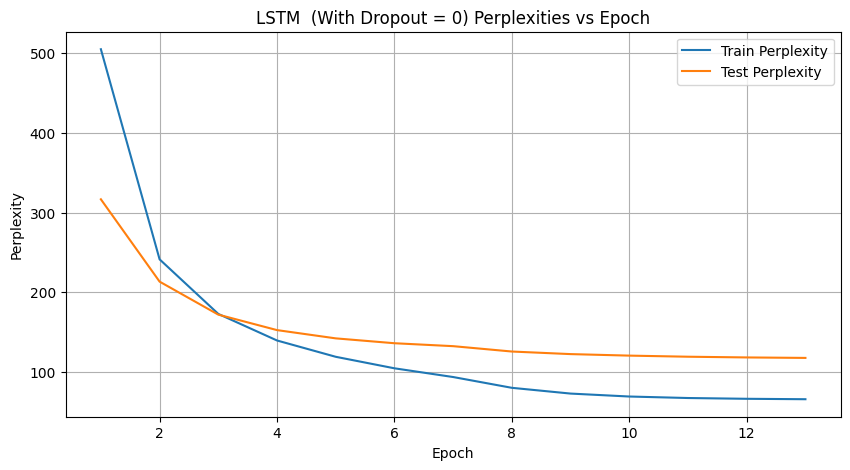

Final Train Perplexity: 65.6332
Final Test Perplexity: 117.4962
Final Validation Perplexity: 120.1541


In [14]:
DROPOUT = 0
LR = 3
DECAY_EPOCH = 7
MAX_EPOCH = 13

model = LSTMModel(VOCAB_SIZE, RNN_SIZE, LAYERS, DROPOUT).to(device)
optimizer = optim.SGD(model.parameters(), lr=LR)
criterion = nn.CrossEntropyLoss()

train_perplexity_lstm, val_perplexity_lstm, test_perplexity_lstm = train_and_evaluate(
    model, train_data, valid_data, test_data, optimizer, criterion,
    SEQ_LENGTH, MAX_EPOCH, DECAY_EPOCH, "lstm_model.pth", "LSTM  (With Dropout = " + str(DROPOUT) + ") Perplexities vs Epoch"
)

print(f"Final Train Perplexity: {train_perplexity_lstm:.4f}")
print(f"Final Test Perplexity: {test_perplexity_lstm:.4f}")
print(f"Final Validation Perplexity: {val_perplexity_lstm:.4f}")

### OPTIONAL: **Infer With Trained Model** (example)

In [16]:
model = LSTMModel(VOCAB_SIZE, RNN_SIZE, LAYERS, DROPOUT).to(device)

model.load_state_dict(torch.load("lstm_model.pth"))
model.eval()

def predict(model, data):
    model.eval()
    with torch.no_grad():
        output = model(data)
    return output

<ipython-input-16-fd7662958665>:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("lstm_model.pth"))



Example inference


```
test_input = torch.tensor([your_test_sequence], dtype=torch.long)  # Replace with actual test data
output = predict(model, test_input)
print(f"Inference result: {output}")
```



# LSTM *With Dropout* Evaluation


#### Evaluated on word-level perplexity as a function of training epoch


##### PARAMETERS

1.   **Dropout = 0.33 %**
2.   **Learning Rate = 6**
3.   **Learning Rate Decay Epoch = 20**
4.   **Number of Epochs = 30**

Epoch 1, Train Perplexity: 446.2948, Val Perplexity: 264.9007, Test Perplexity: 259.5014
Epoch 2, Train Perplexity: 237.0386, Val Perplexity: 199.0421, Test Perplexity: 194.2191
Epoch 3, Train Perplexity: 187.6935, Val Perplexity: 169.7125, Test Perplexity: 165.4333
Epoch 4, Train Perplexity: 161.9801, Val Perplexity: 152.4128, Test Perplexity: 148.3203
Epoch 5, Train Perplexity: 145.6542, Val Perplexity: 141.1066, Test Perplexity: 137.7445
Epoch 6, Train Perplexity: 134.2087, Val Perplexity: 133.3983, Test Perplexity: 130.5248
Epoch 7, Train Perplexity: 125.3345, Val Perplexity: 127.2366, Test Perplexity: 123.6473
Epoch 8, Train Perplexity: 118.0466, Val Perplexity: 121.7195, Test Perplexity: 118.9906
Epoch 9, Train Perplexity: 112.3501, Val Perplexity: 119.5117, Test Perplexity: 116.2528
Epoch 10, Train Perplexity: 107.6942, Val Perplexity: 115.8851, Test Perplexity: 113.0273
Epoch 11, Train Perplexity: 103.6644, Val Perplexity: 114.2721, Test Perplexity: 111.4399
Epoch 12, Train Per

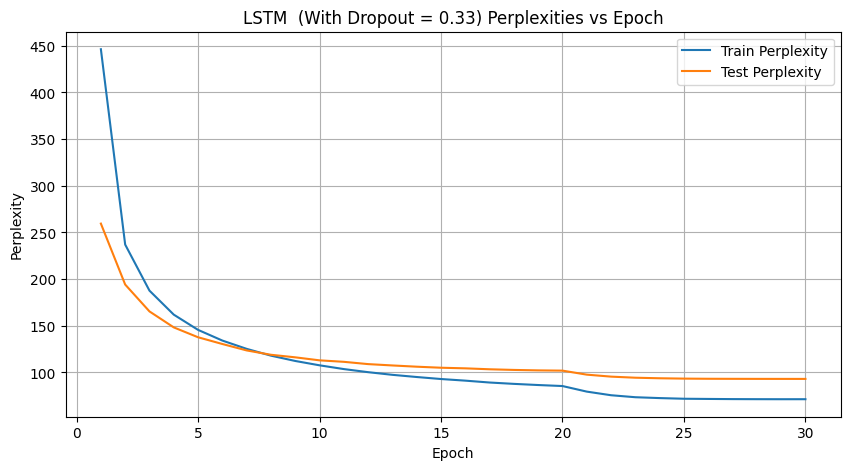

Final Train Perplexity: 71.3923
Final Test Perplexity: 93.1329
Final Validation Perplexity: 96.6946


In [17]:
DROPOUT = 0.33
LR = 6
DECAY_EPOCH = 20
MAX_EPOCH = 30


model_dropout = LSTMModel(VOCAB_SIZE, RNN_SIZE, LAYERS, DROPOUT).to(device)
optimizer = optim.SGD(model_dropout.parameters(), lr=LR)
criterion = nn.CrossEntropyLoss()

train_perplexity_do, val_perplexity_do, test_perplexity_do = train_and_evaluate (
    model_dropout, train_data, valid_data, test_data, optimizer, criterion,
    SEQ_LENGTH, MAX_EPOCH, DECAY_EPOCH, "lstm_model_dropout.pth", "LSTM  (With Dropout = " + str(DROPOUT) + ") Perplexities vs Epoch"
)

print(f"Final Train Perplexity: {train_perplexity_do:.4f}")
print(f"Final Test Perplexity: {test_perplexity_do:.4f}")
print(f"Final Validation Perplexity: {val_perplexity_do:.4f}")

### OPTIONAL: **Infer With Trained Model** (example)

In [ ]:
model = LSTMModel(VOCAB_SIZE, RNN_SIZE, LAYERS, DROPOUT).to(device)

model.load_state_dict(torch.load("lstm_model_dropout.pth"))
model.eval()

def predict(model, data):
    model.eval()
    with torch.no_grad():
        output = model(data)
    return output


Example inference


```
test_input = torch.tensor([your_test_sequence], dtype=torch.long)  # Replace with actual test data
output = predict(model, test_input)
print(f"Inference result: {output}")
```



# Gated Recurrent Units (**GRU**) Model (PyTorch nn.Module)

In [18]:
class GRUModel(nn.Module):
    def __init__(self, vocab_size, rnn_size, layers, dropout):
        super(GRUModel, self).__init__()
        self.drop = nn.Dropout(dropout)
        self.encoder = nn.Embedding(vocab_size, rnn_size)
        self.gru = nn.GRU(rnn_size, rnn_size, layers, dropout=dropout)
        self.decoder = nn.Linear(rnn_size, vocab_size)
        self.init_weights()
        self.rnn_size = rnn_size
        self.layers = layers

    def init_weights(self):
        initrange = INIT_WEIGHT
        self.encoder.weight.data.uniform_(-initrange, initrange)
        self.decoder.weight.data.uniform_(-initrange, initrange)
        self.decoder.bias.data.zero_()

    def forward(self, input, hidden):
        emb = self.drop(self.encoder(input))
        output, hidden = self.gru(emb, hidden)
        output = self.drop(output)
        decoded = self.decoder(output.view(output.size(0) * output.size(1), output.size(2)))
        return decoded.view(output.size(0), output.size(1), decoded.size(1)), hidden

    def init_hidden(self, bsize):
        weight = next(self.parameters())
        return weight.new_zeros(LAYERS, bsize, RNN_SIZE)

#GRU (no dropout) Evaluation

#### Evaluated on word-level perplexity as a function of training epoch

##### PARAMETERS


1.   **Dropout = 0.00 %**
2.   **Learning Rate = 1**
3.   **Learning Rate Decay Epoch = 7**
4.   **Number of Epochs = 13**



Epoch 1, Train Perplexity: 481.8344, Val Perplexity: 310.9702, Test Perplexity: 303.3149
Epoch 2, Train Perplexity: 238.7533, Val Perplexity: 220.9622, Test Perplexity: 214.9021
Epoch 3, Train Perplexity: 177.3604, Val Perplexity: 184.5714, Test Perplexity: 179.4188
Epoch 4, Train Perplexity: 145.6650, Val Perplexity: 164.3662, Test Perplexity: 160.0780
Epoch 5, Train Perplexity: 125.1619, Val Perplexity: 151.4204, Test Perplexity: 147.5866
Epoch 6, Train Perplexity: 110.4704, Val Perplexity: 143.5366, Test Perplexity: 139.9079
Epoch 7, Train Perplexity: 99.2207, Val Perplexity: 138.6271, Test Perplexity: 135.1693
Learning rate reduced to: 0.5000
Epoch 8, Train Perplexity: 86.0511, Val Perplexity: 130.6532, Test Perplexity: 126.7509
Learning rate reduced to: 0.2500
Epoch 9, Train Perplexity: 79.6581, Val Perplexity: 126.2541, Test Perplexity: 122.2769
Learning rate reduced to: 0.1250
Epoch 10, Train Perplexity: 76.4350, Val Perplexity: 124.0832, Test Perplexity: 120.1150
Learning rate 

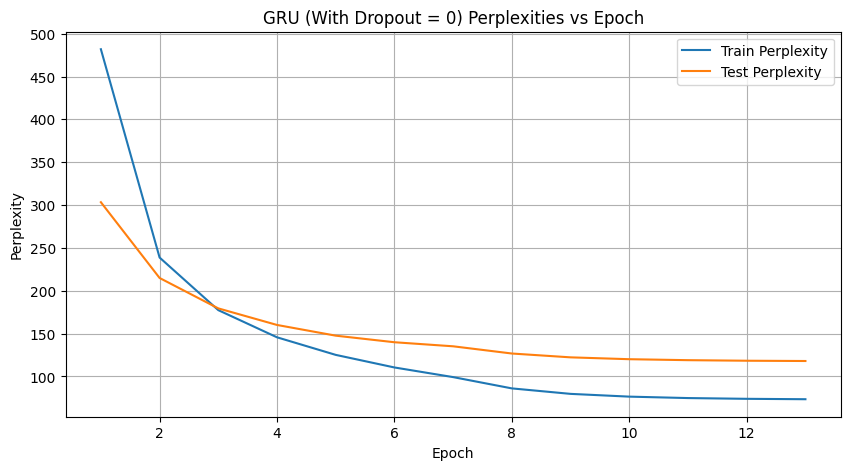

Final Train Perplexity: 73.4174
Final Test Perplexity: 118.0094
Final Validation Perplexity: 122.1770


In [19]:
DROPOUT = 0
LR = 1
DECAY_EPOCH = 7
MAX_EPOCH = 13

model_gru_no_drop = GRUModel(VOCAB_SIZE, RNN_SIZE, LAYERS, DROPOUT).to(device)
optimizer = optim.SGD(model_gru_no_drop.parameters(), lr=LR)
criterion = nn.CrossEntropyLoss()

train_perplexity_gru, val_perplexity_gru, test_perplexity_gru = train_and_evaluate(
    model_gru_no_drop, train_data, valid_data, test_data, optimizer, criterion,
    SEQ_LENGTH, MAX_EPOCH, DECAY_EPOCH, "gru_model.pth", "GRU (With Dropout = " + str(DROPOUT) + ") Perplexities vs Epoch"
)

print(f"Final Train Perplexity: {train_perplexity_gru:.4f}")
print(f"Final Test Perplexity: {test_perplexity_gru:.4f}")
print(f"Final Validation Perplexity: {val_perplexity_gru:.4f}")

### OPTIONAL: **Infer With Trained Model** (example)

In [ ]:
model = GRUModel(VOCAB_SIZE, RNN_SIZE, LAYERS, DROPOUT).to(device)

model.load_state_dict(torch.load("gru_model.pth.pth"))
model.eval()

def predict(model, data):
    model.eval()
    with torch.no_grad():
        output = model(data)
    return output


Example inference


```
test_input = torch.tensor([your_test_sequence], dtype=torch.long)  # Replace with actual test data
output = predict(model, test_input)
print(f"Inference result: {output}")
```



#GRU *With Dropout*  Evaluation

#### Evaluated on word-level perplexity as a function of training epoch

##### PARAMETERS


1.   **Dropout = 0.30**
2.   **Learning Rate = 2**
3.   **Learning Rate Decay Epoch = 25**
4.   **Number of Epochs = 35**



Epoch 1, Train Perplexity: 413.6564, Val Perplexity: 254.8470, Test Perplexity: 250.4243
Epoch 2, Train Perplexity: 225.5899, Val Perplexity: 194.5159, Test Perplexity: 190.3365
Epoch 3, Train Perplexity: 179.6632, Val Perplexity: 167.3917, Test Perplexity: 164.3849
Epoch 4, Train Perplexity: 155.3816, Val Perplexity: 151.2993, Test Perplexity: 148.2877
Epoch 5, Train Perplexity: 139.4198, Val Perplexity: 142.5603, Test Perplexity: 139.8739
Epoch 6, Train Perplexity: 128.1006, Val Perplexity: 135.6985, Test Perplexity: 133.6507
Epoch 7, Train Perplexity: 119.5196, Val Perplexity: 131.4364, Test Perplexity: 128.6441
Epoch 8, Train Perplexity: 112.8136, Val Perplexity: 127.7117, Test Perplexity: 125.1882
Epoch 9, Train Perplexity: 107.7422, Val Perplexity: 125.8443, Test Perplexity: 123.2712
Epoch 10, Train Perplexity: 103.2516, Val Perplexity: 123.5647, Test Perplexity: 121.0400
Epoch 11, Train Perplexity: 99.4710, Val Perplexity: 121.6640, Test Perplexity: 119.0794
Epoch 12, Train Perp

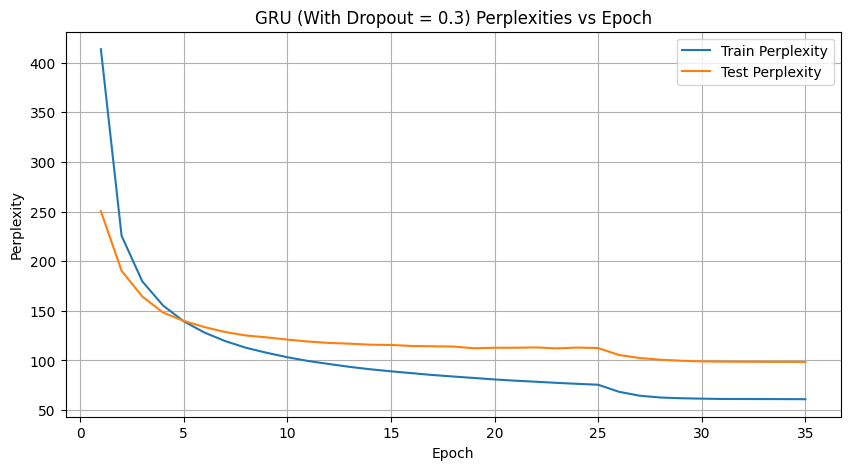

Final Train Perplexity: 60.9409
Final Test Perplexity: 98.5551
Final Validation Perplexity: 102.1842


In [20]:
DROPOUT = 0.30
LR = 2
DECAY_EPOCH = 25
MAX_EPOCH = 35

model_gru_drop = GRUModel(VOCAB_SIZE, RNN_SIZE, LAYERS, DROPOUT).to(device)
optimizer = optim.SGD(model_gru_drop.parameters(), lr=LR)
criterion = nn.CrossEntropyLoss()

train_perplexity_gru_drop, val_perplexity_gru_drop, test_perplexity_gru_drop = train_and_evaluate(
    model_gru_drop, train_data, valid_data, test_data, optimizer, criterion,
    SEQ_LENGTH, MAX_EPOCH, DECAY_EPOCH, "gru_model_dropout.pth", "GRU (With Dropout = " + str(DROPOUT) + ") Perplexities vs Epoch"
)

print(f"Final Train Perplexity: {train_perplexity_gru_drop:.4f}")
print(f"Final Test Perplexity: {test_perplexity_gru_drop:.4f}")
print(f"Final Validation Perplexity: {val_perplexity_gru_drop:.4f}")

###Table of Results

In [21]:
from tabulate import tabulate

table_data = [
    ["Model", "Train Perplexity", "Test Perplexity", "Validation Perplexity"],
    ["LSTM (No Dropout)", train_perplexity_lstm, test_perplexity_lstm, val_perplexity_lstm],
    ["LSTM (With Dropout)", train_perplexity_do, test_perplexity_do, val_perplexity_do],
    ["GRU (No Dropout)", train_perplexity_gru, test_perplexity_gru, val_perplexity_gru],
    ["GRU (With Dropout)", train_perplexity_gru_drop, test_perplexity_gru_drop, val_perplexity_gru_drop]
]

print(tabulate(table_data, headers="firstrow", tablefmt="grid"))


+---------------------+--------------------+-------------------+-------------------------+
| Model               |   Train Perplexity |   Test Perplexity |   Validation Perplexity |
+=====================+====================+===================+=========================+
| LSTM (No Dropout)   |            65.6332 |          117.496  |                120.154  |
+---------------------+--------------------+-------------------+-------------------------+
| LSTM (With Dropout) |            71.3923 |           93.1329 |                 96.6946 |
+---------------------+--------------------+-------------------+-------------------------+
| GRU (No Dropout)    |            73.4174 |          118.009  |                122.177  |
+---------------------+--------------------+-------------------+-------------------------+
| GRU (With Dropout)  |            60.9409 |           98.5551 |                102.184  |
+---------------------+--------------------+-------------------+-------------------------+

### OPTIONAL: **Infer With Trained Model** (example)

In [ ]:
model = GRUModel(VOCAB_SIZE, RNN_SIZE, LAYERS, DROPOUT).to(device)

model.load_state_dict(torch.load("gru_model_dropout.pth.pth"))
model.eval()

def predict(model, data):
    model.eval()
    with torch.no_grad():
        output = model(data)
    return output


Example inference


```
test_input = torch.tensor([your_test_sequence], dtype=torch.long)  # Replace with actual test data
output = predict(model, test_input)
print(f"Inference result: {output}")
```

